##**Actividad 3: Taller EDA**

Entrega: 03 de junio

Instrucciones:

Escoge un conjunto de datos de tu interés (https://www.kaggle.com/datasets)

Utilizando Pandas, realiza:
1. Exploración de datos nulos, datos duplicados, cantidad de filas y
columnas.
2. Limpieza de datos (Pandas: dropna, fillna, replace, etc.)
3. Filtrado y selección de datos relevantes para tu análisis
4. Transformación de columnas, creación de variables nuevas
5. Agrupaciones y resúmenes (groupby)

Formula al menos 5 preguntas de análisis sobre tu conjunto de datos.

Responde a las pregunta planteadas con una gráfica (con título, nombres en
los ejes, leyendas, etc) y una breve interpretación. 
Find Open Datasets for AI and Research | Kaggle
Browse and download hundreds of thousands of open datasets for AI research, model training, and analysis. Join a community of millions of researchers, developers, and builders to share and collaborate on Kaggle.
Image

In [64]:
import pandas as pd

import numpy as np

import requests 

import matplotlib.pyplot as plt

# recordar la importancia de instalar el bash de kaggel:  pip install kaggle

In [ ]:
##Comandos para instalar y configurar kaggle en el entorno del kernel (Jupyter, Colab, etc.):

# 1) Ver qué intérprete usa el kernel
import sys, os
print("python:", sys.executable)

# 2) Comprobar si el archivo de token existe (Windows y Unix)
home = os.path.expanduser("~")
path1 = os.path.join(home, ".kaggle", "access_token")
path2 = os.path.join(os.environ.get("USERPROFILE",""), ".kaggle", "access_token")
print("~/.kaggle/access_token exists:", os.path.exists(path1))
print("%USERPROFILE%\\.kaggle\\access_token exists:", os.path.exists(path2))

# 3) Instalar/actualizar kaggle en el mismo entorno del kernel
import sys
!{sys.executable} -m pip install --upgrade pip kaggle

# 4) Probar la CLI usando el intérprete del kernel (evita depender de PATH)
!{sys.executable} -m kaggle datasets list


In [ ]:
#probar que la CLI funciona descargando un dataset y confirmando que los archivos quedan accesibles desde VS Code.

import sys
!{sys.executable} -m kaggle datasets download owner/dataset-name -p ./data --unzip
!ls -la ./data


In [ ]:
## Probar que la CLI funciona descargando un dataset y confirmando que los archivos quedan accesibles desde VS Code.

import sys
!{sys.executable} -m kaggle datasets download leandroiber/ufc-stats-complete-dataset -p ./data --unzip
!ls -la ./data

In [ ]:
#confirmar que los archivos están accesibles desde Python

import os
print(os.listdir("data"))

['clean_ufc_dataset.csv', 'win_and_title_data-ufc.json']


In [19]:
#traerlos a pandas

df = pd.read_csv("data/clean_ufc_dataset.csv")
df.head()

,event_name,event_date,fighter_1,fighter_2,method,round_num,time,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,...,f2_Stance,f2_DOB,f1_Sig_str_landed,f1_Sig_str_attempted,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted
0,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Gabriel Bonfim,Randy Brown,KO/TKO,2,01:40,185.42,77.11,182.88,...,Orthodox,1990-07-08,35.0,64.0,0.0,0.0,33.0,87.0,0.0,0.0
1,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Joseph Morales,Matt Schnell,Submission,1,02:54,167.64,56.70,175.26,...,Orthodox,1990-01-15,4.0,11.0,1.0,1.0,5.0,11.0,0.0,0.0
2,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Uros Medic,Muslim Salikhov,KO/TKO,1,01:03,185.42,77.11,180.34,...,Orthodox,1984-06-09,2.0,5.0,0.0,0.0,8.0,13.0,0.0,0.0
3,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Chris Padilla,Ismael Bonfim,KO/TKO,2,04:30,175.26,70.31,187.96,...,Orthodox,1995-12-28,64.0,109.0,0.0,0.0,42.0,84.0,1.0,3.0
4,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Christian Leroy Duncan,Marco Tulio,KO/TKO,2,03:20,187.96,83.91,200.66,...,Orthodox,1994-06-13,23.0,46.0,1.0,1.0,27.0,57.0,2.0,5.0


## **Limpieza**

In [ ]:
## obtenemos información general del dataframe para entender su estructura, tipos de datos, y valores faltantes.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8709 entries, 0 to 8708
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8709 non-null   str    
 1   event_date            8709 non-null   str    
 2   fighter_1             8709 non-null   str    
 3   fighter_2             8709 non-null   str    
 4   method                8709 non-null   str    
 5   round_num             8709 non-null   int64  
 6   time                  8709 non-null   str    
 7   f1_Height_cm          8705 non-null   str    
 8   f1_Weight_kg          8706 non-null   float64
 9   f1_Reach_cm           8377 non-null   float64
 10  f2_Height_cm          8687 non-null   str    
 11  f2_Weight_kg          8690 non-null   float64
 12  f2_Reach_cm           7720 non-null   float64
 13  event_url             8709 non-null   str    
 14  fight_url             8709 non-null   str    
 15  fighter_1_url         8709 non-n

In [21]:
## filtramos los valores nullos de las columna f1_Height_cm

nullos_f1_Height_cm = df[df["f1_Height_cm"].isnull()]
nullos_f1_Height_cm

,event_name,event_date,fighter_1,fighter_2,method,round_num,time,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,...,f2_Stance,f2_DOB,f1_Sig_str_landed,f1_Sig_str_attempted,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted
8268,UFC - Ultimate Brazil,1998-10-16,Tulio Palhares,Adriano Santos,KO/TKO,1,09:00,NaN,81.65,NaN,...,NaN,NaN,31.0,44.0,4.0,4.0,11.0,36.0,2.0,3.0
8269,UFC - Ultimate Brazil,1998-10-16,Cesar Marscucci,Paulo Santos,KO/TKO,1,10:27,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8317,UFC 13: The Ultimate Force,1997-05-30,Jack Nilson,Saeed Hosseini,KO/TKO,1,01:23,NaN,NaN,NaN,...,NaN,NaN,11.0,13.0,0.0,0.0,1.0,5.0,0.0,0.0
8438,UFC 2: No Way Out,1994-03-11,Frank Hamaker,Thaddeus Luster,Submission,1,04:52,NaN,NaN,NaN,...,NaN,NaN,2.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0


In [24]:
# Convertimos a números las columnas de altura y peso para poder calcular la media (y otras estadísticas) y así limpiar los valores nullos.

df["f1_Height_cm"] = pd.to_numeric(df["f1_Height_cm"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8709 entries, 0 to 8708
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8709 non-null   str    
 1   event_date            8709 non-null   str    
 2   fighter_1             8709 non-null   str    
 3   fighter_2             8709 non-null   str    
 4   method                8709 non-null   str    
 5   round_num             8709 non-null   int64  
 6   time                  8709 non-null   str    
 7   f1_Height_cm          8640 non-null   float64
 8   f1_Weight_kg          8706 non-null   float64
 9   f1_Reach_cm           8377 non-null   float64
 10  f2_Height_cm          8687 non-null   str    
 11  f2_Weight_kg          8690 non-null   float64
 12  f2_Reach_cm           7720 non-null   float64
 13  event_url             8709 non-null   str    
 14  fight_url             8709 non-null   str    
 15  fighter_1_url         8709 non-n

In [34]:
## Limpiamos los valores nullos de la columna f1_Height_cm reemplazándolos por la media de la columna.

df_limpio = df.copy()
df_limpio["f1_Height_cm"] = df_limpio["f1_Height_cm"].fillna(df["f1_Height_cm"].mean())

In [ ]:
## Revisar si hay valores nulos en la columna f1_Height_cm después de la limpieza.

nullos_f1_Height_cm = df_limpio[df_limpio["f1_Height_cm"].isnull()]

nullos_f1_Height_cm

,event_name,event_date,fighter_1,fighter_2,method,round_num,time,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,...,f2_Stance,f2_DOB,f1_Sig_str_landed,f1_Sig_str_attempted,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted


In [38]:
df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 8709 entries, 0 to 8708
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8709 non-null   str    
 1   event_date            8709 non-null   str    
 2   fighter_1             8709 non-null   str    
 3   fighter_2             8709 non-null   str    
 4   method                8709 non-null   str    
 5   round_num             8709 non-null   int64  
 6   time                  8709 non-null   str    
 7   f1_Height_cm          8709 non-null   float64
 8   f1_Weight_kg          8706 non-null   float64
 9   f1_Reach_cm           8377 non-null   float64
 10  f2_Height_cm          8687 non-null   str    
 11  f2_Weight_kg          8690 non-null   float64
 12  f2_Reach_cm           7720 non-null   float64
 13  event_url             8709 non-null   str    
 14  fight_url             8709 non-null   str    
 15  fighter_1_url         8709 non-n

In [42]:
## limpieza de la columna f1_Weight_kg

df_limpio["f1_Weight_kg"] = df_limpio["f1_Weight_kg"].fillna(df["f1_Weight_kg"].mean())
df_limpio["f1_Reach_cm"] = df_limpio["f1_Reach_cm"].fillna(df["f1_Reach_cm"].mean())

df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 8709 entries, 0 to 8708
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8709 non-null   str    
 1   event_date            8709 non-null   str    
 2   fighter_1             8709 non-null   str    
 3   fighter_2             8709 non-null   str    
 4   method                8709 non-null   str    
 5   round_num             8709 non-null   int64  
 6   time                  8709 non-null   str    
 7   f1_Height_cm          8709 non-null   float64
 8   f1_Weight_kg          8709 non-null   float64
 9   f1_Reach_cm           8709 non-null   float64
 10  f2_Height_cm          8687 non-null   str    
 11  f2_Weight_kg          8690 non-null   float64
 12  f2_Reach_cm           7720 non-null   float64
 13  event_url             8709 non-null   str    
 14  fight_url             8709 non-null   str    
 15  fighter_1_url         8709 non-n

In [45]:
## eliminar valores


df_limpio = df_limpio.dropna(subset=['f2_Height_cm'])

df_limpio.info()

<class 'pandas.DataFrame'>
Index: 8687 entries, 0 to 8708
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8687 non-null   str    
 1   event_date            8687 non-null   str    
 2   fighter_1             8687 non-null   str    
 3   fighter_2             8687 non-null   str    
 4   method                8687 non-null   str    
 5   round_num             8687 non-null   int64  
 6   time                  8687 non-null   str    
 7   f1_Height_cm          8687 non-null   float64
 8   f1_Weight_kg          8687 non-null   float64
 9   f1_Reach_cm           8687 non-null   float64
 10  f2_Height_cm          8687 non-null   str    
 11  f2_Weight_kg          8687 non-null   float64
 12  f2_Reach_cm           7718 non-null   float64
 13  event_url             8687 non-null   str    
 14  fight_url             8687 non-null   str    
 15  fighter_1_url         8687 non-null  

In [ ]:
## Eliminar la columna f2_Reach_cm, que tiene muchos valores nulos y no es relevante para nuestro análisis.

df_limpio = df_limpio.drop(columns=['f2_Reach_cm'])



In [48]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 8687 entries, 0 to 8708
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8687 non-null   str    
 1   event_date            8687 non-null   str    
 2   fighter_1             8687 non-null   str    
 3   fighter_2             8687 non-null   str    
 4   method                8687 non-null   str    
 5   round_num             8687 non-null   int64  
 6   time                  8687 non-null   str    
 7   f1_Height_cm          8687 non-null   float64
 8   f1_Weight_kg          8687 non-null   float64
 9   f1_Reach_cm           8687 non-null   float64
 10  f2_Height_cm          8687 non-null   str    
 11  f2_Weight_kg          8687 non-null   float64
 12  event_url             8687 non-null   str    
 13  fight_url             8687 non-null   str    
 14  fighter_1_url         8687 non-null   str    
 15  fighter_2_url         8687 non-null  

In [ ]:
## convertir columna f2_Height_cm a numérica para poder analizarla

df_limpio["f2_Height_cm"] = pd.to_numeric(df_limpio["f2_Height_cm"], errors="coerce")

df_limpio.info()

In [51]:
df_limpio = df_limpio.dropna(subset=['f2_Height_cm'])

df_limpio.info()

<class 'pandas.DataFrame'>
Index: 8618 entries, 0 to 8708
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_name            8618 non-null   str    
 1   event_date            8618 non-null   str    
 2   fighter_1             8618 non-null   str    
 3   fighter_2             8618 non-null   str    
 4   method                8618 non-null   str    
 5   round_num             8618 non-null   int64  
 6   time                  8618 non-null   str    
 7   f1_Height_cm          8618 non-null   float64
 8   f1_Weight_kg          8618 non-null   float64
 9   f1_Reach_cm           8618 non-null   float64
 10  f2_Height_cm          8618 non-null   float64
 11  f2_Weight_kg          8618 non-null   float64
 12  event_url             8618 non-null   str    
 13  fight_url             8618 non-null   str    
 14  fighter_1_url         8618 non-null   str    
 15  fighter_2_url         8618 non-null  

## 4. **Creación de variables nuevas**

In [56]:
# Relación Peso  entre los luchadores
df_limpio["relacion_peso_f1_f2"] = df_limpio["f1_Height_cm"]/df_limpio["f1_Weight_kg"] 

df_limpio.head(-100)


,event_name,event_date,fighter_1,fighter_2,method,round_num,time,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,...,f2_DOB,f1_Sig_str_landed,f1_Sig_str_attempted,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted,relacion_peso_f1_f2
0,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Gabriel Bonfim,Randy Brown,KO/TKO,2,01:40,185.42,77.11,182.88,...,1990-07-08,35.0,64.0,0.0,0.0,33.0,87.0,0.0,0.0,2.404617
1,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Joseph Morales,Matt Schnell,Submission,1,02:54,167.64,56.70,175.26,...,1990-01-15,4.0,11.0,1.0,1.0,5.0,11.0,0.0,0.0,2.956614
2,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Uros Medic,Muslim Salikhov,KO/TKO,1,01:03,185.42,77.11,180.34,...,1984-06-09,2.0,5.0,0.0,0.0,8.0,13.0,0.0,0.0,2.404617
3,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Chris Padilla,Ismael Bonfim,KO/TKO,2,04:30,175.26,70.31,187.96,...,1995-12-28,64.0,109.0,0.0,0.0,42.0,84.0,1.0,3.0,2.492675
4,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Christian Leroy Duncan,Marco Tulio,KO/TKO,2,03:20,187.96,83.91,200.66,...,1994-06-13,23.0,46.0,1.0,1.0,27.0,57.0,2.0,5.0,2.240019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8595,UFC Fight Night: Moreno vs. Kavanagh,2026-02-28,Damian Pinas,Wes Schultz,KO/TKO,1,02:30,185.42,83.91,200.66,...,1996-08-09 00:00:00,15.0,23.0,0.0,0.0,3.0,13.0,0.0,6.0,2.209749
8596,UFC Fight Night: Strickland vs. Hernandez,2026-02-21,Sean Strickland,Anthony Hernandez,KO/TKO,3,02:23,185.42,83.91,193.04,...,1993-10-18 00:00:00,110.0,241.0,0.0,0.0,55.0,122.0,0.0,1.0,2.209749
8597,UFC Fight Night: Strickland vs. Hernandez,2026-02-21,Uros Medic,Geoff Neal,KO/TKO,1,01:19,185.42,77.11,180.34,...,1990-08-28 00:00:00,3.0,10.0,0.0,0.0,10.0,19.0,0.0,0.0,2.404617
8598,UFC Fight Night: Strickland vs. Hernandez,2026-02-21,Melquizael Costa,Dan Ige,KO/TKO,1,04:56,177.80,65.77,180.34,...,1991-08-06 00:00:00,7.0,11.0,1.0,3.0,19.0,40.0,1.0,1.0,2.703360


In [ ]:
# Relacion peso altura f1

df_limpio["relacion_peso/estatura_f1"] = df_limpio["f1_Weight_kg"]/df_limpio["f1_Height_cm"]

In [58]:
# Relacion peso altura f2

df_limpio["relacion_peso/estatura_f2"] = df_limpio["f2_Weight_kg"]/df_limpio["f2_Height_cm"]

# **Columna Condicional**

In [59]:
## Quien puede ganar por peso/altura?

df_limpio['quien_gana'] = np.where(
    df_limpio['relacion_peso/estatura_f2'] > df_limpio['relacion_peso/estatura_f1'], 'gana f2',
    np.where(
        df_limpio['relacion_peso/estatura_f1'] > df_limpio['relacion_peso/estatura_f2'], 'gana f1',
        'empate'
    )
)


In [60]:
df_limpio.head(-100)

,event_name,event_date,fighter_1,fighter_2,method,round_num,time,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,...,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted,relacion_peso_f1_f2,relacion_peso/estatura_f1,relacion_peso/estatura_f2,quien_gana
0,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Gabriel Bonfim,Randy Brown,KO/TKO,2,01:40,185.42,77.11,182.88,...,0.0,0.0,33.0,87.0,0.0,0.0,2.404617,0.415867,0.404777,gana f1
1,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Joseph Morales,Matt Schnell,Submission,1,02:54,167.64,56.70,175.26,...,1.0,1.0,5.0,11.0,0.0,0.0,2.956614,0.338225,0.328277,gana f1
2,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Uros Medic,Muslim Salikhov,KO/TKO,1,01:03,185.42,77.11,180.34,...,0.0,0.0,8.0,13.0,0.0,0.0,2.404617,0.415867,0.427581,gana f2
3,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Chris Padilla,Ismael Bonfim,KO/TKO,2,04:30,175.26,70.31,187.96,...,0.0,0.0,42.0,84.0,1.0,3.0,2.492675,0.401175,0.407075,gana f2
4,UFC Fight Night: Bonfim vs. Brown,2025-11-08,Christian Leroy Duncan,Marco Tulio,KO/TKO,2,03:20,187.96,83.91,200.66,...,1.0,1.0,27.0,57.0,2.0,5.0,2.240019,0.446425,0.458825,gana f2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8595,UFC Fight Night: Moreno vs. Kavanagh,2026-02-28,Damian Pinas,Wes Schultz,KO/TKO,1,02:30,185.42,83.91,200.66,...,0.0,0.0,3.0,13.0,0.0,6.0,2.209749,0.452540,0.452540,empate
8596,UFC Fight Night: Strickland vs. Hernandez,2026-02-21,Sean Strickland,Anthony Hernandez,KO/TKO,3,02:23,185.42,83.91,193.04,...,0.0,0.0,55.0,122.0,0.0,1.0,2.209749,0.452540,0.458825,gana f2
8597,UFC Fight Night: Strickland vs. Hernandez,2026-02-21,Uros Medic,Geoff Neal,KO/TKO,1,01:19,185.42,77.11,180.34,...,0.0,0.0,10.0,19.0,0.0,0.0,2.404617,0.415867,0.427581,gana f2
8598,UFC Fight Night: Strickland vs. Hernandez,2026-02-21,Melquizael Costa,Dan Ige,KO/TKO,1,04:56,177.80,65.77,180.34,...,1.0,3.0,19.0,40.0,1.0,1.0,2.703360,0.369910,0.386473,gana f2


# **Agrupaciones y resúmenes (groupby)**

## **Resultados por único luchador**

In [61]:
df_resultados = df_limpio.groupby('fighter_1')['quien_gana'].value_counts().unstack(fill_value=0)

print(df_resultados)

quien_gana        empate  gana f1  gana f2
fighter_1                                 
AJ Dobson              0        0        1
AJ Fletcher            0        1        0
Aaron Riley            1        1        1
Aaron Rosa             0        0        1
Aaron Simpson          0        0        7
...                  ...      ...      ...
Zhang Lipeng           0        0        2
Zhang Mingyang         0        3        0
Zhang Tiequan          0        1        0
Zhang Weili            1        4        5
Zubaira Tukhugov       0        5        1

[1898 rows x 3 columns]


# **Resumen estadistico**

In [62]:
df_limpio.describe()

,round_num,f1_Height_cm,f1_Weight_kg,f1_Reach_cm,f2_Height_cm,f2_Weight_kg,f1_KD,f2_KD,f1_Sig_str_landed,f1_Sig_str_attempted,f1_Td_landed,f1_Td_attempted,f2_Sig_str_landed,f2_Sig_str_attempted,f2_Td_landed,f2_Td_attempted,relacion_peso_f1_f2,relacion_peso/estatura_f1,relacion_peso/estatura_f2
count,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8608.000000,8608.000000,8608.000000,8608.000000,8608.000000,8608.000000,8608.000000,8608.000000,8608.000000,8608.000000,8610.000000,8610.000000,8610.000000
mean,2.355303,178.638191,76.151759,183.114620,178.284245,75.921797,0.245353,0.185293,39.130925,84.840962,1.214568,2.969331,34.698885,79.975372,0.909038,2.692960,2.424795,0.423747,0.423313
std,1.017661,10.433074,16.506605,12.118095,10.391040,16.743986,0.516917,0.465301,33.074307,71.240369,1.822579,3.786720,31.438982,69.432660,1.554545,3.722753,0.379686,0.074192,0.075802
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.201099,0.292118,0.306499
25%,1.000000,172.720000,65.770000,177.800000,172.720000,65.770000,0.000000,0.000000,14.000000,29.000000,0.000000,0.000000,10.000000,25.000000,0.000000,0.000000,2.206977,0.369081,0.369910
50%,3.000000,178.558178,77.110000,182.880000,177.800000,70.310000,0.000000,0.000000,31.000000,68.000000,0.000000,1.000000,26.000000,63.000000,0.000000,1.000000,2.437557,0.410247,0.407075
75%,3.000000,185.420000,83.910000,190.500000,185.420000,83.910000,0.000000,0.000000,56.000000,122.000000,2.000000,4.000000,50.000000,117.000000,1.000000,4.000000,2.709430,0.453108,0.453108
max,5.000000,210.820000,156.490000,213.360000,210.820000,349.270000,5.000000,6.000000,445.000000,744.000000,21.000000,37.000000,241.000000,510.000000,19.000000,49.000000,3.423278,0.832571,1.718848


## Grafico de dispersión segpun peso f1

In [66]:
# Agrupamos

df_peso = df_limpio['f1_Weight_kg'].value_counts().reset_index()
df_peso.columns = ['f1_Weight_kg', 'peso']

print(df_peso)


    f1_Weight_kg  peso
0      77.110000  1515
1      70.310000  1370
2      83.910000  1164
3      61.230000  1076
4      65.770000   839
..           ...   ...
63    131.540000     1
64     87.540000     1
65    133.810000     1
66     76.049595     1
67    117.480000     1

[68 rows x 2 columns]


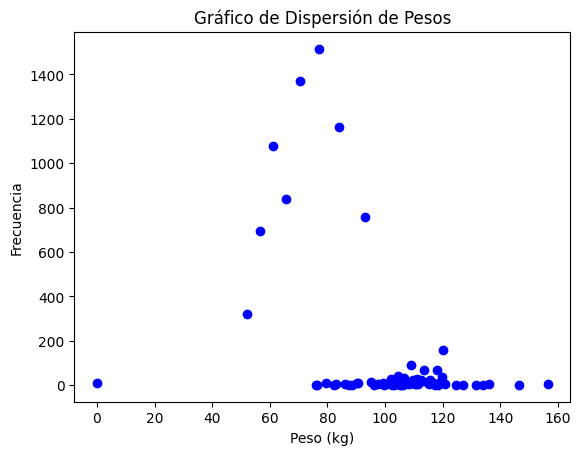

In [ ]:
# Graficamos

import matplotlib.pyplot as plt

#  agrupado  df_peso
plt.scatter(df_peso['f1_Weight_kg'], df_peso['peso'], color='blue')

# agregar título y etiquetas
plt.title('Gráfico de Dispersión de Pesos')
plt.xlabel('Peso (kg)')
plt.ylabel('Frecuencia')

# mostrar el gráfico
plt.show()


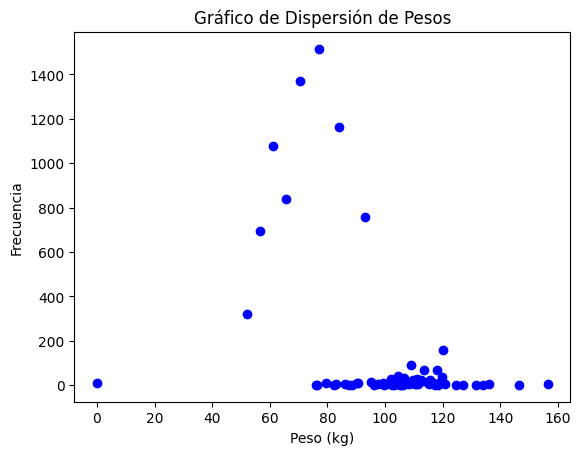

In [67]:
# Datos filtrados

df_peso_filtrado = df_peso[df_peso['f1_Weight_kg'] != 1]

# graficamos
plt.scatter(df_peso_filtrado['f1_Weight_kg'], df_peso_filtrado['peso'], color='blue')

# agregar título y etiquetas
plt.title('Gráfico de Dispersión de Pesos')
plt.xlabel('Peso (kg)')
plt.ylabel('Frecuencia')

# mostrar el gráfico
plt.show()


Evidenciamos que los pesos son muy relativos. Sí hay gran agrupación de pesos similares en las partes altas de la grafica.